# 06 — Local Explainability: SHAP Case Studies + PDP/ICE (Albania 2022)

Notebook 05 gave the *global* picture (which features matter overall). This notebook is the *local* half of the story, mirroring `scripts/run_explainability_cases.py`:

1. One representative **TP / TN / FP / FN** instance, each with a SHAP **waterfall** — why the model was confidently right, and confidently wrong.
2. **PDP + centered-ICE** curves for the top drivers — the *shape* of each feature's effect and the instance-level heterogeneity (interactions) the average hides.

The explanatory model is a single LightGBM fit on all Albania-2022 data (fit-on-all is fine for explanation, not evaluation), on the **school-context** feature set (student + school-mean features). LightGBM is imported before scikit-learn (import-order libomp fix), so the booster fit and SHAP run live in-kernel.

## Methods & formulas (reference)

**Local SHAP (waterfall).** For one student the signed $\phi_i$ (log-odds) stack
from the base value $\phi_0=\mathbb{E}[f]$ to the prediction
$f(x)=\phi_0+\sum_i\phi_i$ (local accuracy). Red $\phi_i>0$ push toward at-risk,
blue $\phi_i<0$ toward proficient.

**Partial Dependence (PDP).** Marginal effect of feature $S$, averaging over the
other features' empirical distribution:
$$\text{PDP}_S(v)=\frac1n\sum_{k=1}^{n} f\big(v,\,x^{(k)}_{\setminus S}\big).$$

**Individual Conditional Expectation (ICE).** One curve per instance,
$\text{ICE}^{(k)}_S(v)=f(v,x^{(k)}_{\setminus S})$; the PDP is their average.
**Centered ICE** anchors each curve at the grid start,
$\text{ICE}^{(k)}(v)-\text{ICE}^{(k)}(v_0)$, so heterogeneous slopes — the
fingerprint of interactions — show up where the average curve hides them.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
try:
    import lightgbm  # noqa: F401 - load its Homebrew libomp BEFORE sklearn's (import-order fix, avoids rc=-11)
except Exception:
    pass
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.explainability.shap_analysis import (
    compute_local_shap, compute_shap_values, global_feature_importance,
    select_representative_cases)
from src.explainability.partial_dependence import centered_ice, compute_pdp
from src.features.transformers import EngineeredFeatureBuilder
from src.models.prepare import build_model_data, impute_median
from src.models.registry import get_model

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math', add_school_context=True)
X_eng = EngineeredFeatureBuilder().fit_transform(data.X)
(X,) = impute_median(X_eng); y = data.y.values
model = get_model('lightgbm'); model.fit(X, y, sample_weight=data.weights.values)
print('trained on', X.shape, '| at-risk rate =', round(float(y.mean()),3))

2026-07-03 11:39:45 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-07-03 11:39:45 [info     ] School aggregates added        cols=['ESCS', 'HOMEPOS', 'ANXMAT', 'TEACHSUP'] n_schools=274


2026-07-03 11:39:45 [info     ] Feature selection complete     n_features=18


2026-07-03 11:39:45 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=31 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


trained on (6129, 39) | at-risk rate = 0.754


## 1. Representative confusion-matrix cases

For each quadrant we pick the *most confident* instance — a confidently correct case (TP/TN) and a confidently **wrong** case (FP/FN), whose local SHAP explanation is most informative.

In [3]:
cases = select_representative_cases(model, X, y)
pd.DataFrame([{'quadrant':k, **{kk:vv for kk,vv in c.items() if kk!='index'}}
              for k,c in cases.items()])

,quadrant,label,prob,y_true,y_pred
0,TP,true positive,0.996720,1,1
1,TN,true negative,0.012187,0,0
2,FP,false positive,0.881403,0,1
3,FN,false negative,0.071042,1,0


## 2. Local SHAP waterfalls

Signed feature contributions (log-odds) from the model base value toward each instance's prediction. **Red = pushes toward at-risk, blue = pushes toward proficient.**

2026-07-03 11:39:46 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


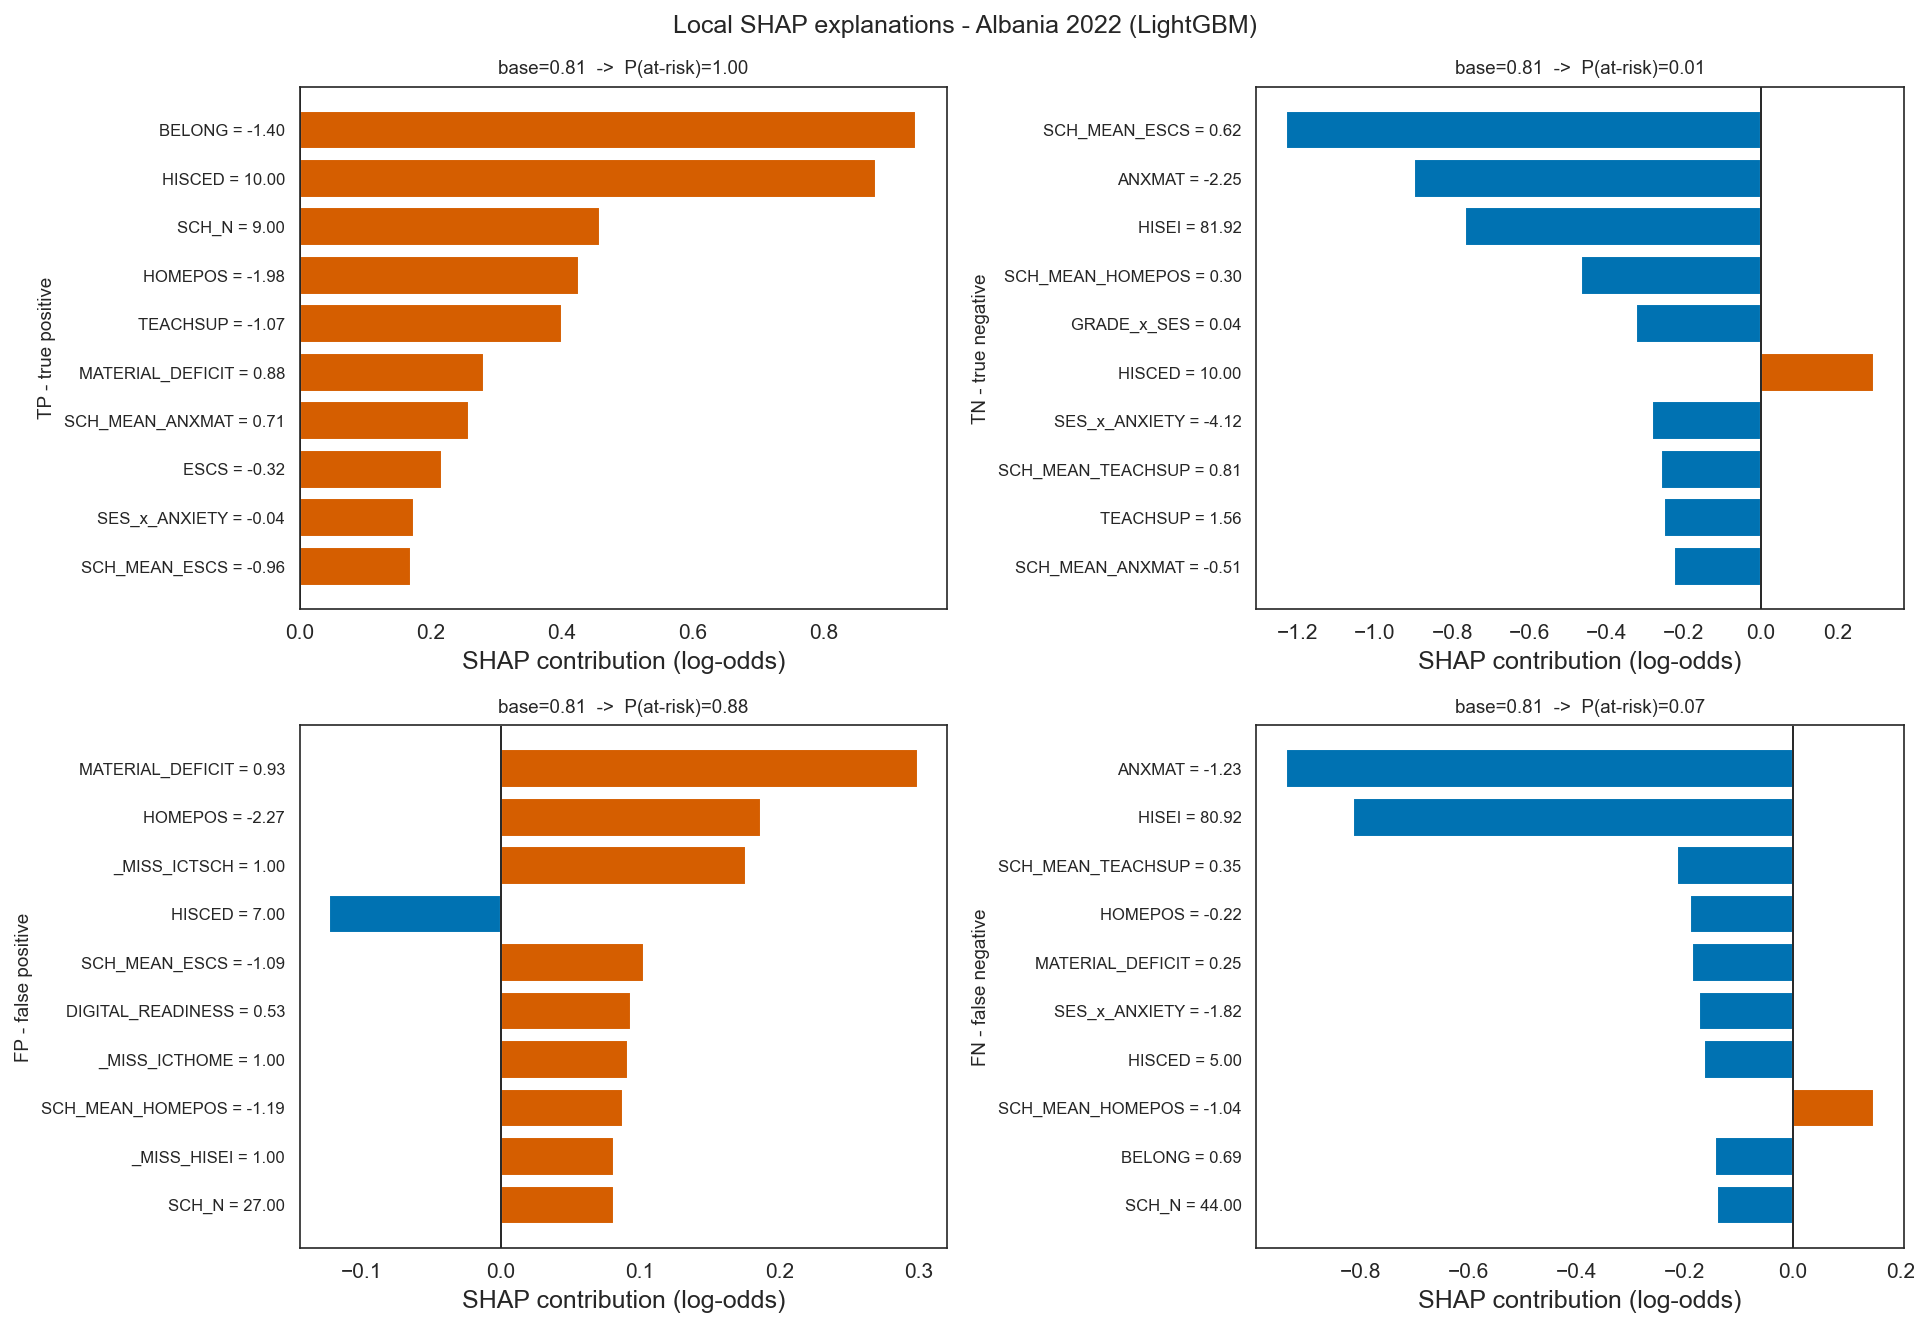

In [4]:
def waterfall(ax, values, base, pred, names, row, top_n=10):
    order = np.argsort(np.abs(values))[::-1][:top_n]
    contrib = values[order]
    labels = [f'{names[i]} = {row[i]:.2f}' for i in order]
    colors = ['#D55E00' if c>0 else '#0072B2' for c in contrib]
    yy = np.arange(len(contrib))[::-1]
    ax.barh(yy, contrib, color=colors); ax.set_yticks(yy)
    ax.set_yticklabels(labels, fontsize=8); ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('SHAP contribution (log-odds)')
    ax.set_title(f'base={base:.2f}  ->  P(at-risk)={pred:.2f}', fontsize=9)

from src.visualization.style import apply_publication_style
apply_publication_style()
idx = [c['index'] for c in cases.values()]
X_bg = X.sample(min(300, len(X)), random_state=42)
vals, base, names = compute_local_shap(model, X.iloc[idx], X_background=X_bg)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (k, c), v, b in zip(axes.ravel(), cases.items(), vals, base):
    waterfall(ax, v, b, c['prob'], names, X.iloc[c['index']].values)
    ax.set_ylabel(f"{k} - {c['label']}", fontsize=9)
fig.suptitle('Local SHAP explanations - Albania 2022 (LightGBM)', fontsize=12)
fig.tight_layout(); plt.show()

**Reading:** the TP/TN waterfalls show the model stacking up **school-context** signals (school-mean home possessions, teacher support, ESCS) alongside individual math anxiety. The FP/FN cases expose where those signals mislead — e.g. a student in a low-resource school who is nonetheless proficient (FP), or a resourced-school student the model misses (FN) — the individual bucking their school context.

## 3. Partial dependence + centered ICE

PDP = mean predicted at-risk probability as one feature varies (all else held). Centered ICE keeps one grey line per instance (anchored to the grid start) so heterogeneity — the fingerprint of interactions — is visible where the average curve hides it.

2026-07-03 11:39:46 [info     ] Subsampling for SHAP           original=6129 sampled=2000


2026-07-03 11:39:46 [info     ] Using TreeSHAP                 model_type=LGBMClassifier


2026-07-03 11:39:46 [info     ] SHAP values computed           shape=(2000, 39)


PDP/ICE for: ['ANXMAT', 'HISCED', 'HOMEPOS', 'BELONG']
2026-07-03 11:39:46 [info     ] PDP computed                   feature=ANXMAT ice=True n_grid=30


2026-07-03 11:39:46 [info     ] PDP computed                   feature=HISCED ice=True n_grid=8


2026-07-03 11:39:47 [info     ] PDP computed                   feature=HOMEPOS ice=True n_grid=30


2026-07-03 11:39:47 [info     ] PDP computed                   feature=BELONG ice=True n_grid=30


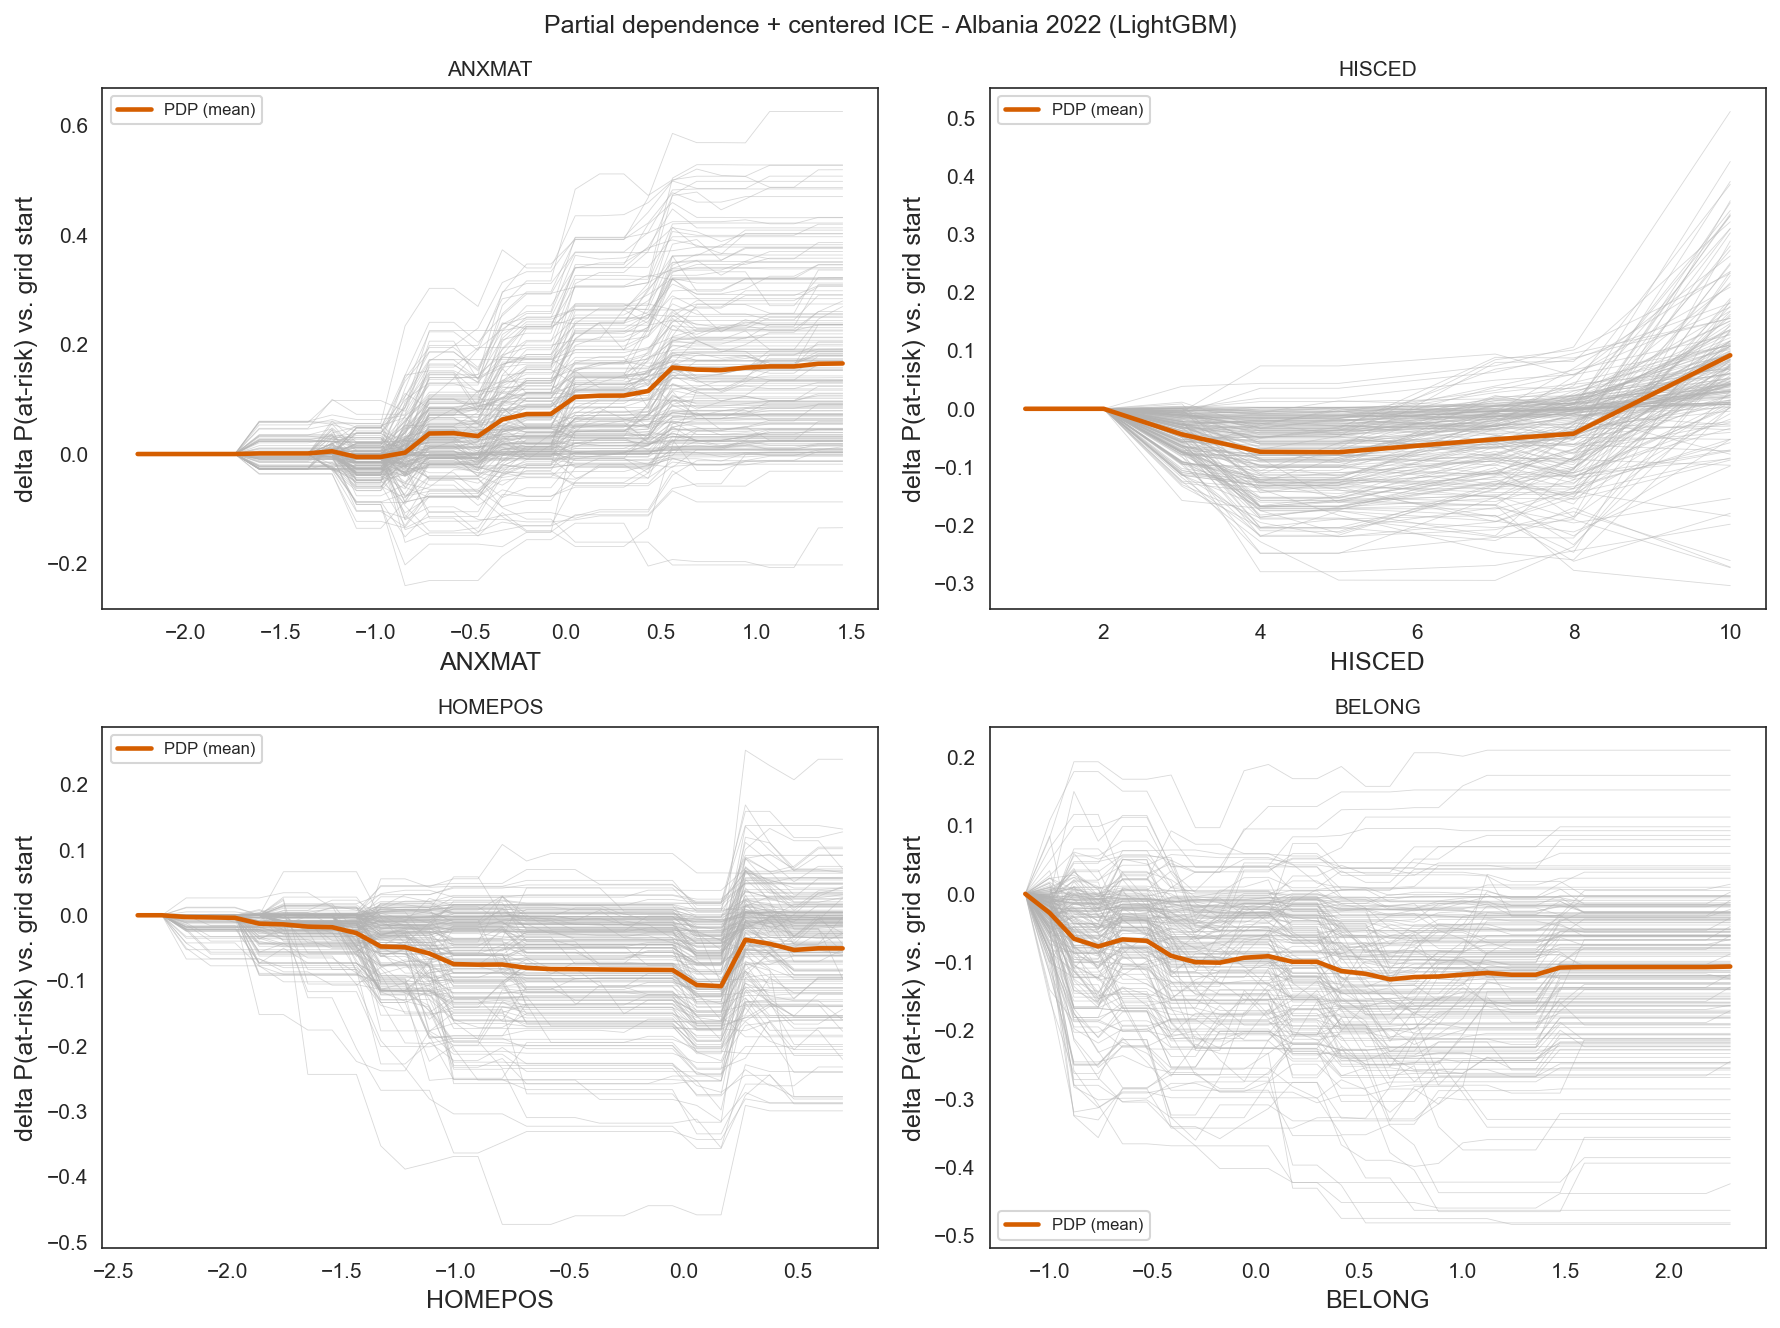

In [5]:
shap_vals, shap_names = compute_shap_values(model, X, X_background=X_bg, max_samples=2000)
imp = global_feature_importance(shap_vals, shap_names)
raw_top = [f for f in imp['feature'] if f in feats][:4]
print('PDP/ICE for:', raw_top)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
rng = np.random.default_rng(42)
for ax, feat in zip(axes.ravel(), raw_top):
    pdp = compute_pdp(model, X, feat, grid_resolution=30, ice=True)
    cice = centered_ice(pdp)
    sub = rng.choice(cice.shape[0], size=min(200, cice.shape[0]), replace=False)
    for r in cice[sub]:
        ax.plot(pdp.grid, r, color='0.7', lw=0.4, alpha=0.5)
    ax.plot(pdp.grid, pdp.average - pdp.average[0], color='#D55E00', lw=2.2, label='PDP (mean)')
    ax.set_title(feat, fontsize=10); ax.set_xlabel(feat)
    ax.set_ylabel('delta P(at-risk) vs. grid start'); ax.legend(fontsize=8)
fig.suptitle('Partial dependence + centered ICE - Albania 2022 (LightGBM)', fontsize=12)
fig.tight_layout(); plt.show()

## Conclusions & Interpretation

- **Local confirms global.** The confidently-correct (TP/TN) waterfalls are dominated by the same drivers notebook 05 flagged globally — **school-context** features (school-mean HOMEPOS/TEACHSUP/ESCS) plus individual math anxiety — so the compositional story isn't an averaging artefact.
- **Where the model fails.** FP/FN cases show the failure mode: the model leans on school context + anxiety, so a student who defies their school's profile (proficient in a low-resource school, or at-risk in a resourced one) is misclassified. Risk is probabilistic, not deterministic, at the individual level.
- **Effect shapes are monotone but heterogeneous.** PDP curves for the top drivers move risk smoothly and roughly monotonically; the ICE spread shows the *magnitude* varies by instance — evidence of interactions (e.g. anxiety's effect moderated by SES).
- **Policy read:** the highest-leverage levers (math anxiety, material support) act on most students but not uniformly — targeting should be individualised, not blanket. Explanations are **associational** (they explain the model), not causal.
- Figures mirror D3 (`D3_shap_local_cases`) and D4 (`D4_pdp_ice`); the case table matches `shap_local_cases_2022.csv`.